# 👩‍💻 Implement and Train a CNN on CIFAR-10

## 📋 Overview
In this lab, you'll implement a Convolutional Neural Network (CNN) from scratch using PyTorch and train it on the CIFAR-10 dataset. CNNs are fundamental to modern computer vision applications - the skills you'll develop here are directly applicable to real-world scenarios like autonomous vehicle image recognition systems, medical diagnostic tools, and automated quality control in manufacturing.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Load and preprocess image datasets with appropriate transformations for CNN training
- Design and implement a custom CNN architecture using PyTorch's neural network modules
- Train a CNN model using optimization techniques including loss functions and gradient descent
- Evaluate model performance using appropriate metrics and visualize predictions

## 🚀 Starting Point
Required tools/setup:

- PyTorch installed (version 1.8+)
- Matplotlib for visualization
- At least 2GB of free disk space for dataset

Make sure to reference:

- The previous lab on neural network fundamentals
- Basic understanding of convolutional operations

## Task 1: Loading and Preparing the CIFAR-10 Dataset
**Context:** In industry applications, properly preparing image data is crucial for model performance. The CIFAR-10 dataset is a standard benchmark containing 60,000 32×32 color images in 10 different classes.

**Steps:**

1. Import the necessary libraries for working with PyTorch and the CIFAR-10 dataset

    - Use `torch`, `torchvision.datasets`, `torchvision.transforms`, and `torch.utils.data`
    - Consider what transformations will normalize the data appropriately

2. Define transformations to prepare the images

    - Apply `transforms.ToTensor()` to convert images to PyTorch tensors
    - Use `transforms.Normalize()` with appropriate mean and standard deviation values
    - Think about: Why is normalization important for neural network training?

3. Load the CIFAR-10 dataset using the defined transformations

    - Use `torchvision.datasets.CIFAR10()` with appropriate parameters
    - Set `download=True` to automatically retrieve the dataset

4. Create data loaders for both training and testing sets

    - Use `torch.utils.data.DataLoader`
    - Consider: How does batch size affect training?
    - What's the purpose of shuffling the training data?

Sample training images:


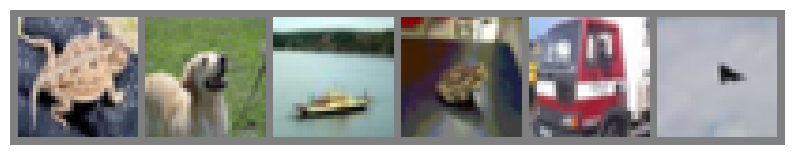

Labels:  frog   dog  ship  frog truck plane


In [1]:
# Import necessary libraries
# Task 1: Loading and preparing the dataset
# Your code here

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Task 1: Loading and preparing the dataset
# Define transformations for image preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 training and test datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# Define classes for CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# Function to display images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
print('Sample training images:')
imshow(torchvision.utils.make_grid(images[:6]))
print('Labels:', ' '.join('%5s' % classes[labels[j]] for j in range(6)))

**💡 Tip:** The CIFAR-10 images are RGB with pixel values from 0-255, so normalizing with mean=(0.5, 0.5, 0.5) and std=(0.5, 0.5, 0.5) scales them to the [-1, 1] range.
This specific normalization (mean=0.5, std=0.5 for each RGB channel) is a common convention that shifts and scales the original [0,1] pixel values (after ToTensor) to a symmetric range of [-1, 1], often leading to more stable training.

**⚙️ Test Your Work:**

- Print the shape of a batch from the data loader - you should see [batch_size, 3, 32, 32]
- Display a few sample images to verify they load correctly

## Task 2: Designing the CNN Architecture
**Context:** When working on image classification projects, choosing the right CNN architecture directly impacts performance. The architecture you design must effectively extract features from the images while balancing computational efficiency.

**Steps:**

1. Create a CNN class that inherits from `nn.Module`

    - Use `torch.nn` to define your neural network
    - Initialize the class with appropriate layers

2. Define convolutional layers to extract image features

    - Use `nn.Conv2d()` to create convolutional layers
    - Consider kernel size, stride, and output channels
    - Think about: How does increasing the number of filters affect feature extraction?

3. Add pooling layers to reduce spatial dimensions

    - Implement `nn.MaxPool2d()` or use functional `F.max_pool2d()`
    - Consider: What's the purpose of pooling in CNNs?

4. Add fully connected layers to perform classification

    - Use `nn.Linear()` for classification layers
    - Calculate the correct input dimensions based on your conv/pool operations
    - Think about: How many output neurons do you need for CIFAR-10?

5. Implement the forward method to connect all layers

    - Define the data flow through your network
    - Add appropriate activation functions (e.g., ReLU)
    - Use proper reshaping between convolutional and linear layers

In [2]:
# Task 2: Designing the CNN Architecture
# Your code here

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # (32x32x3) -> (32x32x32)
        # First pooling layer 
        self.pool1 = nn.MaxPool2d(2, 2)  # (32x32x32) -> (16x16x32)
        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # (16x16x32) -> (16x16x64)
        # Second pooling layer
        self.pool2 = nn.MaxPool2d(2, 2)  # (16x16x64) -> (8x8x64)
        # Third convolutional layer
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)  # (8x8x64) -> (8x8x128)
        # Third pooling layer
        self.pool3 = nn.MaxPool2d(2, 2)  # (8x8x128) -> (4x4x128)
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)  # Flattened output to 512
        self.fc2 = nn.Linear(512, 10)  # 10 output classes
        # Dropout for regularization
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Apply conv layers with ReLU and pooling
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        # Flatten the output for the fully connected layer
        x = x.view(-1, 128 * 4 * 4)
        # Apply dropout for regularization
        x = self.dropout(x)
        # Apply fully connected layers with ReLU
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Create the model
model = CNN()
print(model)

# Test the model with a batch
sample_batch = next(iter(trainloader))[0]
output = model(sample_batch)
print(f"Output shape: {output.shape}")


CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.25, inplace=False)
)
Output shape: torch.Size([64, 10])


**💡 Tip:** Remember to calculate the output dimensions after each convolutional and pooling layer to determine the correct input size for your first fully connected layer.
To calculate the input size for your first fully connected layer, track the spatial dimensions and channel count after each convolutional and pooling operation. For example, if a 32x32 image passes through a pooling layer with kernel_size=2, stride=2, its spatial dimensions will become 16x16. This applies to all channels.

**⚙️ Test Your Work:**

- Create an instance of your model and print its architecture
- Pass a sample batch through the model to verify the output shape is [batch_size, 10]

## Task 3: Training the CNN Model
Context: Training deep learning models requires careful configuration of optimizers, loss functions, and training loops. In production environments, engineers must monitor training progress and adjust parameters accordingly.

**Steps:**

1. Define the loss function and optimizer

    - Use `nn.CrossEntropyLoss()` for multiclass classification
    - Choose an appropriate optimizer (`optim.SGD` or `optim.Adam`)
    - Set a suitable learning rate
    - Consider: How does learning rate affect training stability and speed?

2. Create a training loop to iterate through epochs and batches

    - Loop through a specified number of epochs
    - For each epoch, iterate through the training data loader

3. Implement the forward and backward passes in the training loop

    - Zero gradients with `optimizer.zero_grad()`
    - Compute model outputs and loss
    - Perform backpropagation with `loss.backward()`
    - Update weights with `optimizer.step()`

4. Track and display training progress

    - Calculate running loss during training
    - Print loss statistics at regular intervals
    - Consider: What patterns should you look for in the loss values?

Training on: cuda:0
Starting training...
[Epoch 1, Batch 100] loss: 1.883
[Epoch 1, Batch 200] loss: 1.532
[Epoch 1, Batch 300] loss: 1.448
[Epoch 1, Batch 400] loss: 1.357
[Epoch 1, Batch 500] loss: 1.279
[Epoch 1, Batch 600] loss: 1.209
[Epoch 1, Batch 700] loss: 1.177
[Epoch 2, Batch 100] loss: 1.062
[Epoch 2, Batch 200] loss: 1.040
[Epoch 2, Batch 300] loss: 0.986
[Epoch 2, Batch 400] loss: 0.962
[Epoch 2, Batch 500] loss: 0.969
[Epoch 2, Batch 600] loss: 0.940
[Epoch 2, Batch 700] loss: 0.901
[Epoch 3, Batch 100] loss: 0.820
[Epoch 3, Batch 200] loss: 0.841
[Epoch 3, Batch 300] loss: 0.808
[Epoch 3, Batch 400] loss: 0.789
[Epoch 3, Batch 500] loss: 0.789
[Epoch 3, Batch 600] loss: 0.801
[Epoch 3, Batch 700] loss: 0.779
[Epoch 4, Batch 100] loss: 0.690
[Epoch 4, Batch 200] loss: 0.703
[Epoch 4, Batch 300] loss: 0.692
[Epoch 4, Batch 400] loss: 0.691
[Epoch 4, Batch 500] loss: 0.702
[Epoch 4, Batch 600] loss: 0.697
[Epoch 4, Batch 700] loss: 0.678
[Epoch 5, Batch 100] loss: 0.622
[E

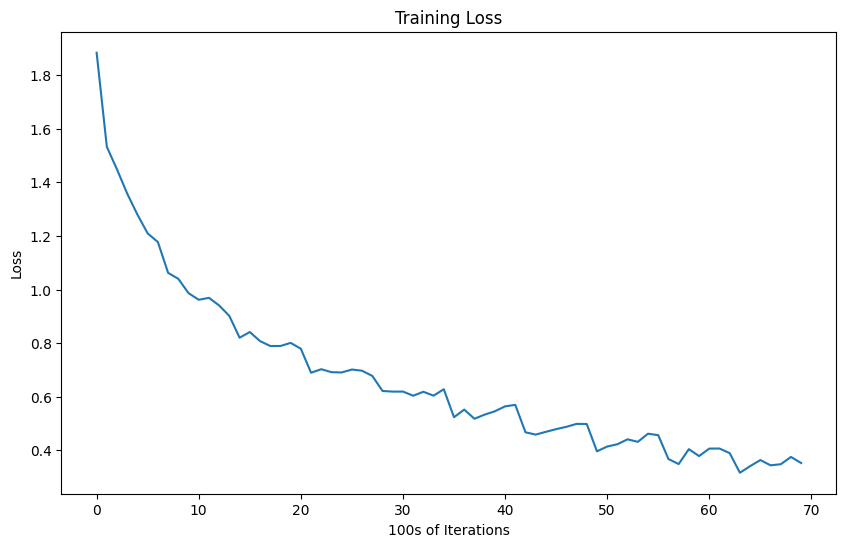

In [3]:
# Task 3: Training the CNN Model
# Your code here

# Choose loss function and optimizer
# CrossEntropyLoss is suitable for multi-class classification, 
# as it combines Softmax and Negative Log Likelihood Loss.
criterion = nn.CrossEntropyLoss()
    
# Define learning rate
LEARNING_RATE = 0.001  
    
# Define the optimizer # Adam is an adaptive learning rate optimizer, 
# generally a good default choice. # It updates model parameters based on # gradients. 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move model to device
model.to(device)

# Number of epochs
num_epochs = 10
train_losses = []

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    running_loss = 0.0
    
    for i, data in enumerate(trainloader, 0):
        # Get inputs and labels, and move them to the device
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        
        # Print statistics every 100 mini-batches
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            train_losses.append(running_loss / 100)
            running_loss = 0.0

print('Training complete!')

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('100s of Iterations')
plt.ylabel('Loss')
plt.show()

**💡 Tip:** To debug training issues, implement a validation step after each epoch to check if the model is learning or overfitting.

**⚙️ Test Your Work:**

- Monitor the loss values during training - they should decrease over time
- Check that validation accuracy improves as training progresses

## Task 4: Evaluating Model Performance
**Context:** In practical applications, model evaluation provides crucial information about deployment readiness. Stakeholders need clear metrics and visualizations to understand model capabilities.

**Steps:**

1. Create an evaluation loop for the test dataset

    - Iterate through the test data loader
    - Use `torch.no_grad()` to disable gradient calculation
    - Think about: Why do we disable gradients during evaluation?

2. Calculate accuracy and other performance metrics

    - Compare model predictions to ground truth labels
    - Compute overall accuracy percentage
    - Consider calculating per-class accuracy

3. Visualize model predictions on sample images

    - Select a batch of test images
    - Get model predictions for these images
    - Display the images with both predicted and actual labels
    - Think about: What patterns do you observe in the model's mistakes?

4. Analyze model performance and identify improvement areas

    - Look for classes that are frequently confused
    - Consider how the model might be improved

Accuracy on 10,000 test images: 77.54%
Accuracy of plane: 81.40%
Accuracy of car: 91.20%
Accuracy of bird: 72.10%
Accuracy of cat: 48.90%
Accuracy of deer: 69.70%
Accuracy of dog: 77.40%
Accuracy of frog: 84.70%
Accuracy of horse: 81.10%
Accuracy of ship: 89.00%
Accuracy of truck: 79.90%


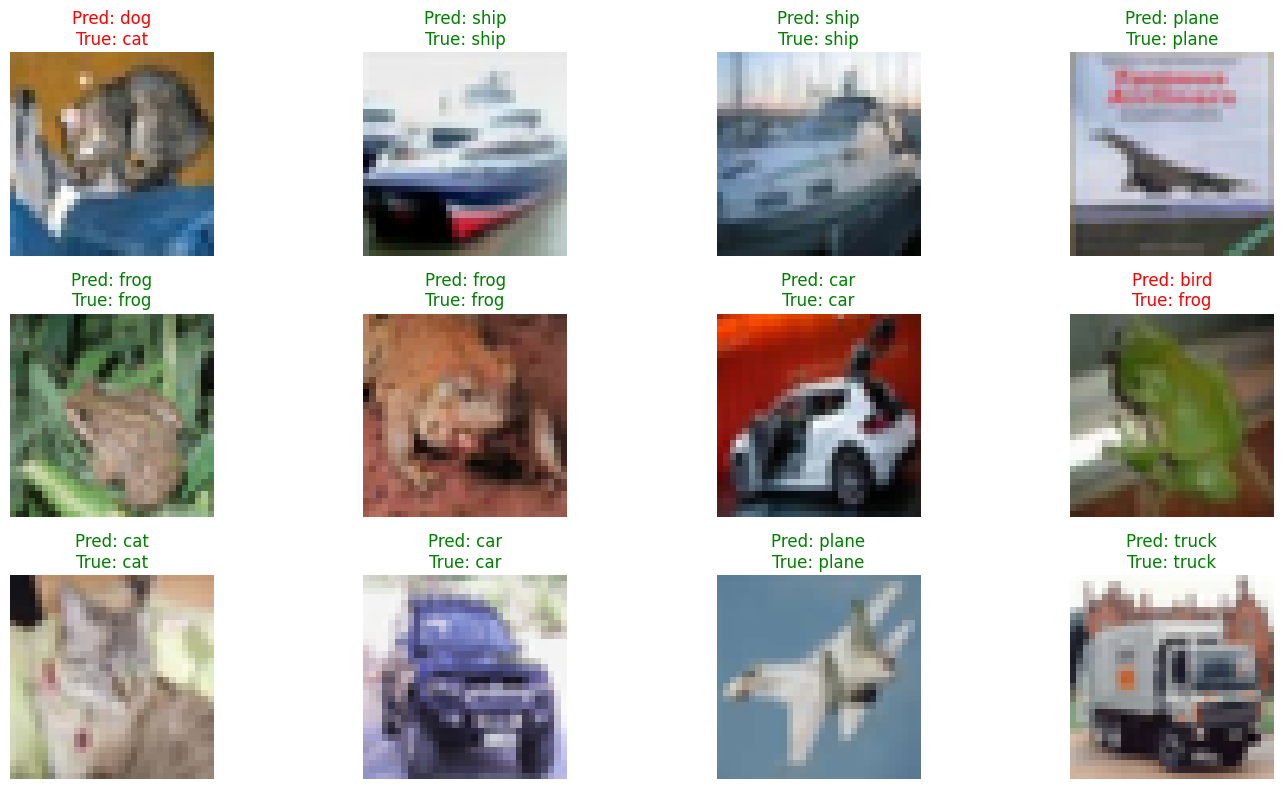

Model saved as 'cifar10_cnn.pth'


In [4]:
# Task 4: Evaluating Model Performance

# Evaluate on test set
model.eval()  # Set to evaluation mode
correct = 0
total = 0

# Class-wise accuracy
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Class accuracy
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

# Overall accuracy
print(f'Accuracy on 10,000 test images: {100 * correct / total:.2f}%')

# Per-class accuracy
for i in range(10):
    print(f'Accuracy of {classes[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')

# Visualize some predictions
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Move images and predictions back to CPU for visualization
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

# Show images with predictions
plt.figure(figsize=(15, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    imshow_single = lambda img: plt.imshow(np.transpose(img.numpy() / 2 + 0.5, (1, 2, 0)))
    imshow_single(images[i])
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f'Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Save the model
torch.save(model.state_dict(), 'cifar10_cnn.pth')
print("Model saved as 'cifar10_cnn.pth'")

**💡 Tip:** Create a confusion matrix to see which classes are most often confused with each other.

**⚙️ Test Your Work:**

- Verify that accuracy calculation is implemented correctly
- Check that visualizations clearly show both correct and incorrect predictions

## ✅ Success Checklist
- Dataset loaded with appropriate transformations
- CNN model architecture defined with convolutional, pooling, and fully connected layers
- Training loop implemented with loss function and optimizer
- Model evaluation showing test accuracy above 50% (baseline for CIFAR-10)
- Visualizations of model predictions that clearly show performance
- Program runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Model accuracy is extremely low (around 10%) **Solution:** Check for normalization issues or ensure your model architecture is correctly implemented.

**Problem:** "CUDA out of memory" error **Solution:** Reduce batch size or simplify model architecture to use fewer parameters.

**Problem:** Dimensions mismatch in linear layer **Solution:** Calculate the exact output size after convolution and pooling layers to set the correct input size for your first linear layer.

**Problem:** Training loss doesn't decrease **Solution:** Verify optimizer setup, try a different learning rate, or check for issues in your model architecture.

## 🔑 Key Points
- Convolutional layers extract spatial features from images, making them ideal for computer vision tasks
- Normalization and preprocessing significantly impact CNN performance and training stability
- Model architecture design requires balancing depth, parameter count, and computational requirements
- Evaluating models requires both quantitative metrics and qualitative analysis of predictions

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Task 1: Loading and preparing the dataset
# Define transformations for image preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 training and test datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64,
                                         shuffle=False, num_workers=2)

# Define classes for CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 
           'dog', 'frog', 'horse', 'ship', 'truck')

# Function to display images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Show images
print('Sample training images:')
imshow(torchvision.utils.make_grid(images[:6]))
print('Labels:', ' '.join('%5s' % classes[labels[j]] for j in range(6)))

# Task 2: Designing the CNN Architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # First convolutional layer
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)  # (32x32x3) -> (32x32x32)
        # First pooling layer 
        self.pool1 = nn.MaxPool2d(2, 2)  # (32x32x32) -> (16x16x32)
        # Second convolutional layer
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)  # (16x16x32) -> (16x16x64)
        # Second pooling layer
        self.pool2 = nn.MaxPool2d(2, 2)  # (16x16x64) -> (8x8x64)
        # Third convolutional layer
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)  # (8x8x64) -> (8x8x128)
        # Third pooling layer
        self.pool3 = nn.MaxPool2d(2, 2)  # (8x8x128) -> (4x4x128)
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)  # Flattened output to 512
        self.fc2 = nn.Linear(512, 10)  # 10 output classes
        # Dropout for regularization
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        # Apply conv layers with ReLU and pooling
        x = self.pool1(torch.relu(self.conv1(x)))
        x = self.pool2(torch.relu(self.conv2(x)))
        x = self.pool3(torch.relu(self.conv3(x)))
        # Flatten the output for the fully connected layer
        x = x.view(-1, 128 * 4 * 4)
        # Apply dropout for regularization
        x = self.dropout(x)
        # Apply fully connected layers with ReLU
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Create the model
model = CNN()
print(model)

# Test the model with a batch
sample_batch = next(iter(trainloader))[0]
output = model(sample_batch)
print(f"Output shape: {output.shape}")

# Task 3: Training the CNN Model
# Choose loss function and optimizer
# CrossEntropyLoss is suitable for multi-class classification, 
# as it combines Softmax and Negative Log Likelihood Loss.
criterion = nn.CrossEntropyLoss()
    
# Define learning rate
LEARNING_RATE = 0.001  
    
# Define the optimizer # Adam is an adaptive learning rate optimizer, 
# generally a good default choice. # It updates model parameters based on # gradients. 
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# Move model to device
model.to(device)

# Number of epochs
num_epochs = 10
train_losses = []

# Training loop
print("Starting training...")
for epoch in range(num_epochs):
    running_loss = 0.0
    
    for i, data in enumerate(trainloader, 0):
        # Get inputs and labels, and move them to the device
        inputs, labels = data[0].to(device), data[1].to(device)
        
        # Zero the parameter gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track statistics
        running_loss += loss.item()
        
        # Print statistics every 100 mini-batches
        if i % 100 == 99:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}')
            train_losses.append(running_loss / 100)
            running_loss = 0.0

print('Training complete!')

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('100s of Iterations')
plt.ylabel('Loss')
plt.show()

# Task 4: Evaluating Model Performance
# Evaluate on test set
model.eval()  # Set to evaluation mode
correct = 0
total = 0

# Class-wise accuracy
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for data in testloader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Class accuracy
        for i in range(labels.size(0)):
            label = labels[i]
            class_correct[label] += (predicted[i] == label).item()
            class_total[label] += 1

# Overall accuracy
print(f'Accuracy on 10,000 test images: {100 * correct / total:.2f}%')

# Per-class accuracy
for i in range(10):
    print(f'Accuracy of {classes[i]}: {100 * class_correct[i] / class_total[i]:.2f}%')

# Visualize some predictions
model.eval()
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get predictions
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Move images and predictions back to CPU for visualization
images = images.cpu()
predicted = predicted.cpu()
labels = labels.cpu()

# Show images with predictions
plt.figure(figsize=(15, 8))
for i in range(12):
    plt.subplot(3, 4, i+1)
    imshow_single = lambda img: plt.imshow(np.transpose(img.numpy() / 2 + 0.5, (1, 2, 0)))
    imshow_single(images[i])
    color = 'green' if predicted[i] == labels[i] else 'red'
    plt.title(f'Pred: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# Save the model
torch.save(model.state_dict(), 'cifar10_cnn.pth')
print("Model saved as 'cifar10_cnn.pth'")
```    